In [20]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..')) 
from solver.quantum_solver.dwave_simulator import DwaveSimulator

def generate_random_ising(n, h_range=(-1, 1), J_range=(-2, 2)):
    #Génère une instance aléatoire du problème d'Ising.
    s = sp.symbols(f's0:{n}')
    expr = 0
    expr += 0.0001 * s[n-1] 
    
    for i in range(n):
        expr += np.random.uniform(h_range[0], h_range[1]) * s[i]
    for i in range(n):
        for j in range(i+1, n):
            expr += np.random.uniform(J_range[0], J_range[1]) * s[i] * s[j]
    return expr

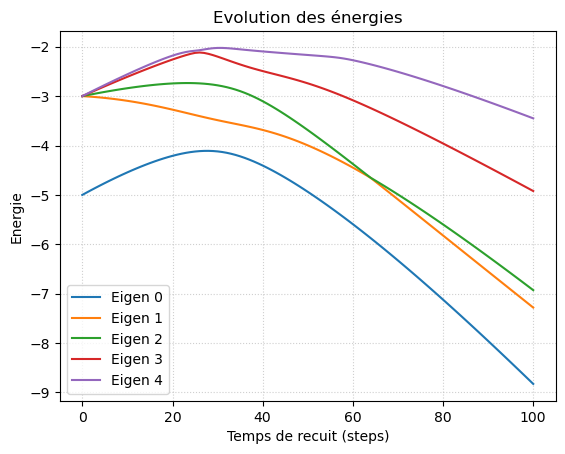

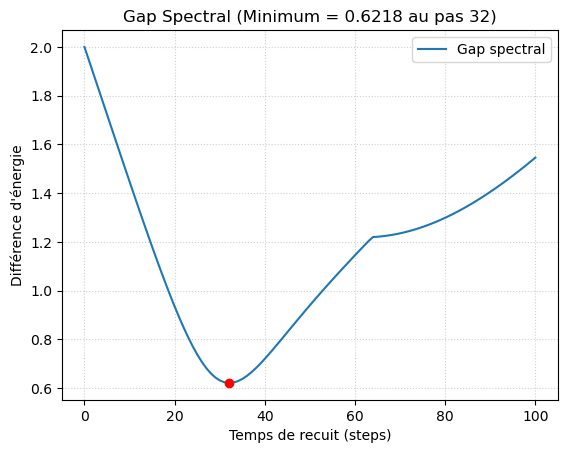

In [21]:
sim = DwaveSimulator()
n_small = 5 
ising_prob = generate_random_ising(n_small)

valeurs_propres = sim.simulate_evolution(ising_prob, nb_eigenvalues=5)

# Tracé des résultats
sim.plot_eigenvalues(valeurs_propres)
sim.plot_spectral_gap(valeurs_propres)

Taille 3 | Gap min : 0.638815
Taille 4 | Gap min : 0.930259
Taille 5 | Gap min : 0.437017
Taille 6 | Gap min : 0.367977
Taille 7 | Gap min : 0.004210


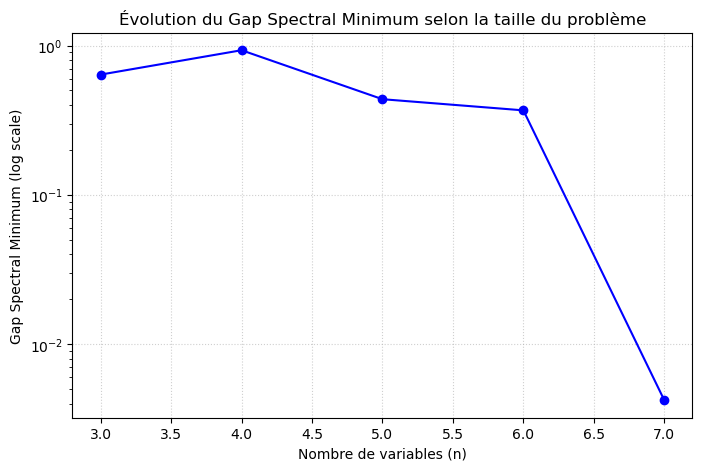

In [22]:
sizes = range(3, 8)
min_gaps_by_size = []


for n in sizes:
    prob = generate_random_ising(n)
    
    val_propres = sim.simulate_evolution(prob, nb_eigenvalues=2)
    
   
    data = np.array(val_propres) 
    
    # Calcul du gap 
    gap = data[:, 1] - data[:, 0]
    min_gaps_by_size.append(np.min(gap))
    print(f"Taille {n} | Gap min : {np.min(gap):.6f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, min_gaps_by_size, marker='o', color='blue')
plt.yscale('log')
plt.title("Évolution du Gap Spectral Minimum selon la taille du problème")
plt.xlabel("Nombre de variables (n)")
plt.ylabel("Gap Spectral Minimum (log scale)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Q: Do you observe any difference concerning the spectral gap? How should it scale with the instance size?



Facteur x0.1 | Gap min : 0.028469
Facteur x0.5 | Gap min : 0.130061
Facteur x1.0 | Gap min : 0.202355
Facteur x2.0 | Gap min : 0.264854
Facteur x10.0 | Gap min : 0.345763


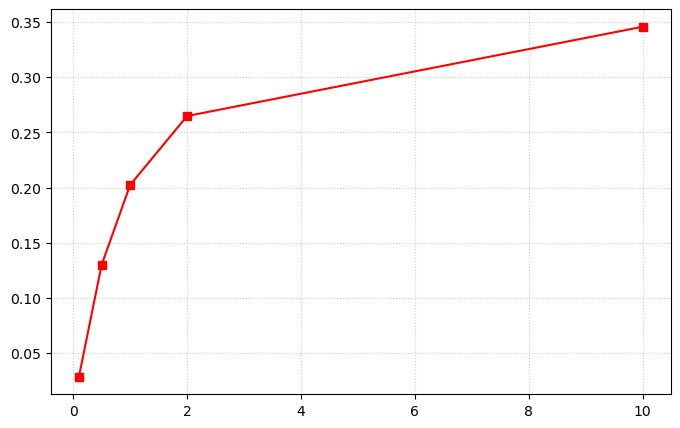

In [23]:
n_test = 5
base_problem = generate_random_ising(n_test)
scale_factors = [0.1, 0.5, 1.0, 2.0, 10.0]
gaps_rescaled = []

for scale in scale_factors:
    # On multiplie toute l'équation par le facteur
    rescaled_problem = base_problem * scale
    
    # Simulation
    val_propres = sim.simulate_evolution(rescaled_problem, nb_eigenvalues=2)
    data = np.array(val_propres)
    
    # Calcul du gap
    gap = data[:, 1] - data[:, 0]
    gaps_rescaled.append(np.min(gap))
    print(f"Facteur x{scale} | Gap min : {np.min(gap):.6f}")

plt.figure(figsize=(8, 5))
plt.plot(scale_factors, gaps_rescaled, marker='s', color='red')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Q: In quantum annealers, the programming range of h_i and J_ij values is always finite
(for example hi ∈ [−1, +1] and hi,j ∈ [−2, +2] ). If we need to rescale the values of
one input problem to solve it with a quantum annealer, does it ease or worsen the
resolution of the problem ? Explain why (take a look at the spectral gap) ?